# Questions this notebook seeks to answer
This notebook is motivated by two questions:
* The *utility score* is defined over a number of days e.g. over the date range of the training dataset, or the mock test / public / private dataset. What if we take a slightly granular look by sliding, say, a 100-day or 200-day window, how would the *utility score* evolve over time?
* How would the above compare between ```resp```, ```resp_1```, ```resp_2```, ```resp_3``` and ```resp_4```?

This notebook calculates the *utility score* as defined under the competition [evaluation tab](https://www.kaggle.com/c/jane-street-market-prediction/overview/evaluation): 
For each ```date``` i, we have

$ p_i = \sum_j (weight_{ij} * resp_{ij} * action_{ij}) $

$ t = \frac{\sum p_i}{\sqrt{\sum p_i^2}} * \sqrt{\frac{250}{\mid i \mid}} $

$ u = min(max(t, 0), 6) \sum p_i $

This is a follow-on notebook from [Day 85 before vs after: a look at utility score](https://www.kaggle.com/marychin/day-85-before-vs-after-a-look-at-utility-score).

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets
from datetime import datetime
from pytz import timezone
print('tic', datetime.now(timezone('Canada/Pacific')).isoformat(timespec='minutes'))

tic 2021-02-18T20:16-08:00


In [2]:
train = pd.read_csv('../input/jane-street-market-prediction/train.csv')

# just slimming down

# remove rows we don't need
train = train.loc[ train['weight']>0 ]

# remove columns we don't need
train = train[ ['resp', 'resp_1', 'resp_2', 'resp_3', 'resp_4', 'date', 'weight'] ]

targets = ['resp', 'resp_1', 'resp_2', 'resp_3', 'resp_4']

# Step 1: $ p_i = \sum_j (weight_{ij} * resp_{ij} * action_{ij}) $
* I'm going to use ```dailyp``` to represent $p_i$. Not using ```pi```, which would feel like $\pi$.
* Sanity check for the next cell was already done in a preceding notebook, [Day 85 before vs after: a look at utility score](https://www.kaggle.com/marychin/day-85-before-vs-after-a-look-at-utility-score).

In [3]:
dailyp = pd.DataFrame(index=train['date'].unique(), columns=targets)
dailyp.index.name = 'date'
for ntarget, target in enumerate(targets):
# assuming action=1 when target>0
    df = train.loc[ train[target]>0 ].copy()
    dailyp[target] = df.groupby('date', sort=False).apply(lambda x: (x['weight'] * x[target]).sum())
dailyp

,resp,resp_1,resp_2,resp_3,resp_4
date,,,,,
0,74.558117,19.538497,27.780672,53.504716,90.368050
1,184.730000,48.172580,67.652691,134.196484,249.687307
2,0.006989,0.006712,0.006712,0.006912,0.007231
3,105.354603,34.159279,50.002517,89.086184,141.348514
4,154.658028,42.748569,59.443866,86.375459,175.889727
...,...,...,...,...,...
495,146.376502,40.157188,55.771303,110.822410,199.332633
496,70.537806,23.425204,32.918105,50.221078,85.999295
497,46.358519,11.768816,16.430064,35.162076,64.146594


# Step 2: $ t = \frac{\sum p_i}{\sqrt{\sum p_i^2}} * \sqrt{\frac{250}{\mid i \mid}} $

In [4]:
t = dailyp.apply(lambda x: x.sum() / np.sqrt((x**2).sum()) * np.sqrt(250/len(x)))

# Step 3: $ u = min(max(t, 0), 6) \sum p_i $
Noting the values for ```t``` from the previous cell, ```t``` obviously never gets a chance to be of any effect. 
So, effectively $ u = 6\sum p_i $.

# Utility score for the entire training set

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  This is separate from the ipykernel package so we can avoid doing imports until


resp      224162.268180
resp_1     62431.107713
resp_2     89282.207195
resp_3    158936.177488
resp_4    287026.104245
dtype: float64

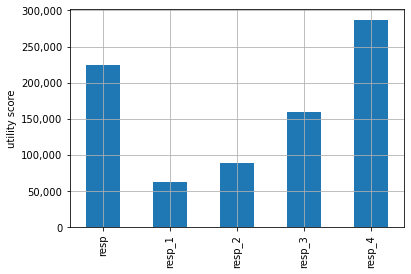

In [5]:
util_all = 6 * dailyp.sum()
ax = util_all.plot.bar(ylabel='utility score', grid=True)
ax.set_yticklabels(['{:,.0f}'.format(x) for x in ax.get_yticks()])
util_all

# Sliding-window utility scores

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  del sys.path[0]


,resp,resp_1,resp_2,resp_3,resp_4
start date,,,,,
0,68725.498504,19335.857291,27573.573583,48832.285334,87703.089818
1,68531.983674,19284.785685,27501.148569,48691.740189,87491.939844
2,67602.106917,19047.038179,27181.116240,48027.287993,86208.995818
3,68428.941985,19265.684626,27512.956166,48624.577800,87260.443134
4,68105.402542,19147.785164,27338.711256,48322.310064,86820.526001
...,...,...,...,...,...
345,71356.994970,19870.131309,28456.661465,50740.515261,91357.933508
346,71228.444447,19844.023383,28393.216115,50633.087701,91219.105446
347,70613.110787,19657.534691,28129.277807,50195.691450,90410.503438


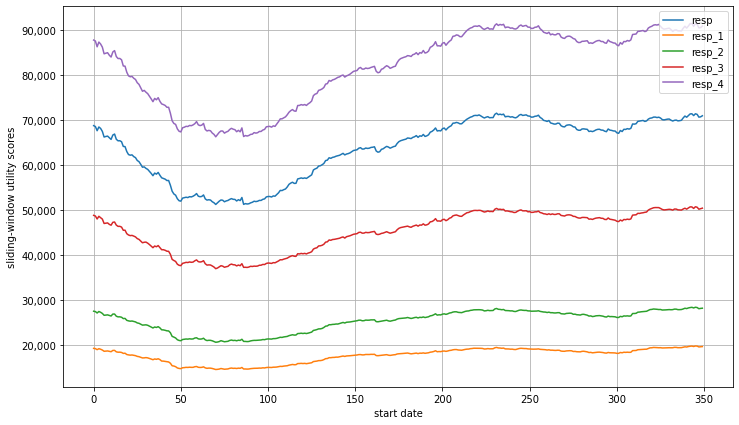

In [6]:
window = 150     # CHANGE TO DESIRED WINDOW WIDTH
window = max(100, min(window, len(dailyp)-2) )
util = pd.DataFrame(index=np.arange(len(dailyp)-window), columns=targets)
for ntarget, target in enumerate(targets):
    for head in range(len(dailyp)-window):
        dailyps = dailyp.loc[head:head+window, target]
        t = dailyps.sum() / np.sqrt((dailyps**2).sum() * np.sqrt(250/window))
        if min(max(t, 0), 6)!=6:
            print('t kicking into effect')
        util.loc[head, target] = 6 * dailyps.sum()
util.index.name = 'start date'
ax = util.plot(ylabel='sliding-window utility scores', grid=True, figsize=(12, 7))
ax.set_yticklabels(['{:,.0f}'.format(x) for x in ax.get_yticks()])
util

In [7]:
# sanity
pick_date = np.random.choice(window)
dailyps = dailyp.loc[ pick_date  :pick_date+window, 'resp_3' ]
auto = util.loc[pick_date, 'resp_3']
manual = 6 * dailyps.sum()
np.testing.assert_allclose(auto, manual)
manual, auto

(44310.358721875135, 44310.358721875135)

In [8]:
print('toc', datetime.now(timezone('Canada/Pacific')).isoformat(timespec='minutes') )

toc 2021-02-18T20:19-08:00
